In [ ]:
#ANN using MNIST

Length of Train dataset: 60000
Length of Test dataset: 10000
Epoch [1/10] Train Loss: 0.3693, Train Acc: 0.8859, Val Loss: 0.1674, Val Acc: 0.9477
Epoch [2/10] Train Loss: 0.1427, Train Acc: 0.9569, Val Loss: 0.1166, Val Acc: 0.9667
Epoch [3/10] Train Loss: 0.1028, Train Acc: 0.9694, Val Loss: 0.0957, Val Acc: 0.9705
Epoch [4/10] Train Loss: 0.0823, Train Acc: 0.9754, Val Loss: 0.0954, Val Acc: 0.9723
Epoch [5/10] Train Loss: 0.0718, Train Acc: 0.9773, Val Loss: 0.0792, Val Acc: 0.9777
Epoch [6/10] Train Loss: 0.0631, Train Acc: 0.9799, Val Loss: 0.0810, Val Acc: 0.9753
Epoch [7/10] Train Loss: 0.0562, Train Acc: 0.9820, Val Loss: 0.0923, Val Acc: 0.9748
Epoch [8/10] Train Loss: 0.0493, Train Acc: 0.9847, Val Loss: 0.0739, Val Acc: 0.9803
Epoch [9/10] Train Loss: 0.0478, Train Acc: 0.9848, Val Loss: 0.0886, Val Acc: 0.9778
Epoch [10/10] Train Loss: 0.0424, Train Acc: 0.9864, Val Loss: 0.0898, Val Acc: 0.9770

Test Accuracy: 0.9800


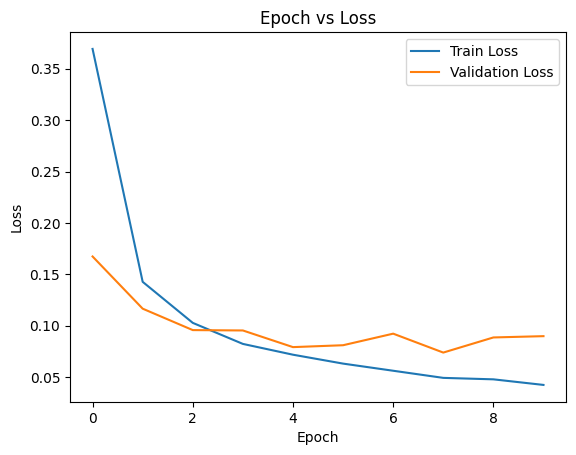

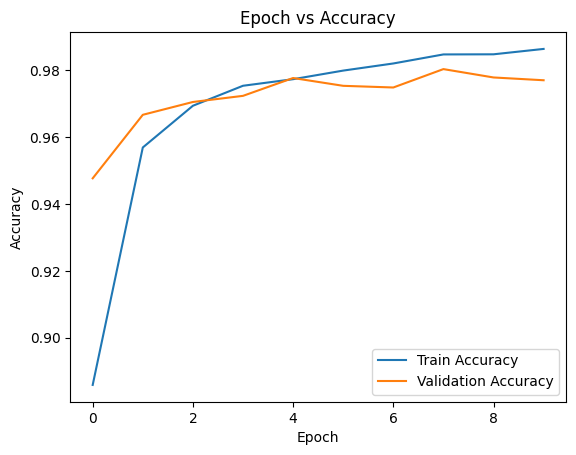

In [ ]:

# Step 1: Imports

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Step 2: Load MNIST Dataset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

print("Length of Train dataset:", len(train_dataset))

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

print("Length of Test dataset:", len(test_dataset))

# Step 3: Train-Validation Split

train_size = int(0.9 * len(train_dataset)) #54000
val_size = len(train_dataset) - train_size #6000

train_dataset, val_dataset = random_split(
    train_dataset, [train_size, val_size]
)


# Step 4: DataLoaders

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Step 5: ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Step 6: Training Setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ANN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Track metrics per epoch
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Step 7: Training Loop

def train_model(model, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()


            preds = outputs.argmax(1)
            train_correct += (preds == y_batch).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / len(train_loader.dataset)

        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)


        # Validation

        model.eval()
        val_correct = 0
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()
                preds = outputs.argmax(1)
                val_correct += (preds == y_batch).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / len(val_loader.dataset)

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}, "
              f"Val Acc: {val_acc:.4f}")

# Train model
train_model(model, train_loader, val_loader, epochs=10)


# Step 8: Test Evaluation

model.eval()
test_correct = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        test_correct += (preds == y_batch).sum().item()

print(f"\nTest Accuracy: {test_correct / len(test_loader.dataset):.4f}")

# Step 9: Plot Graphs


# Loss Graph
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy Graph
plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Epoch vs Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
import torch
import numpy as np

#Creating a tensor
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
print(x_data)

#Creating tensor from numpy array
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(x_np)

#Creating tensor having all 1's
x_ones = torch.ones_like(x_data)
print(f"Ones Tensor: \n {x_ones} \n")

#Creating a random tensor
x_rand = torch.rand_like(x_data, dtype=torch.float)
print(f"Random Tensor: \n {x_rand} \n")

tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]])
Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.2857, 0.9805],
        [0.8026, 0.7689]]) 



In [ ]:
#Attribute of Tensors - Shape, Data type and Device Tensor

tensor = torch.rand(3,4)

print(tensor)
print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

tensor([[0.8419, 0.6285, 0.5356, 0.3540],
        [0.8575, 0.6913, 0.1383, 0.1851],
        [0.7223, 0.3425, 0.0013, 0.4292]])
Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


In [ ]:

a_tensor = torch.tensor([[1,2,3,4,5],[6,7,8,9,10],[11,12,13,14,15],[16,17,18,19,20]]);
print("A_Tensor:",a_tensor,"\n")

print(f"First row:\n {a_tensor[0]}\n")
print(f"First column:\n {a_tensor[:, 0]}\n")
print(f"Second column to Fourth column:\n {a_tensor[:, 1:4]}\n")
print(f"Last column:\n {a_tensor[..., -1]}\n")

print("Change 2nd column values to 0:")
a_tensor[:,1] = 0
print(a_tensor)

A_Tensor: tensor([[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10],
        [11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20]]) 

First row:
 tensor([1, 2, 3, 4, 5])

First column:
 tensor([ 1,  6, 11, 16])

Second column to Fourth column:
 tensor([[ 2,  3,  4],
        [ 7,  8,  9],
        [12, 13, 14],
        [17, 18, 19]])

Last column:
 tensor([ 5, 10, 15, 20])

Change 2nd column values to 0:
tensor([[ 1,  0,  3,  4,  5],
        [ 6,  0,  8,  9, 10],
        [11,  0, 13, 14, 15],
        [16,  0, 18, 19, 20]])


In [ ]:
# Tensor Operation

#Create two random tensors and perform operations.

a = torch.randn(3, 3)
b = torch.randn(3, 3)

print("Tensor A:\n", a)
print("Tensor B:\n", b)

print("Addition:\n", a + b)
print("Matrix Multiplication:\n", torch.matmul(a, b))
print("Mean of A:", a.mean())
print("Maximum Value in Tensor A:", torch.max(a));
print("Minimum Value in Tensor A:", torch.min(a));

print("Maximum Value in Tensor B:" ,torch.max(b));
print("Minimum Value in Tensor B:", torch.min(b));

print("Reshape tensor (3x3 → 1x9):\n", a.reshape(1, 9))
print("Reshape tensor (3x3 → 9x1):\n", a.reshape(9, 1))

reshaped_A_Tensor = a.reshape(3,3, 1)
print("Reshape tensor (3x3 → 3x3x1):\n", reshaped_A_Tensor) #3 rows 3 columns and 1 depth

"""
2D
[
 [a, b, c]
 [d, e, f]
 [g, h, i]
]

3D
[
 [[a],
  [b],
  [c]],

 [[d],
  [e],
  [f]],

 [[g],
  [h],
  [i]]
]

Accessing h

Row 0 → [[a],[b],[c]]
Row 1 → [[d],[e],[f]]
Row 2 → [[g],[h],[i]]

Inside row 2:
Column 0 → [g]
Column 1 → [h]
Column 2 → [i]

So h is located at:
row = 2
column = 1
depth = 0

"""

#Access 0.0916
print(reshaped_A_Tensor[1][1][0])

Tensor A:
 tensor([[ 0.6029, -0.4036,  1.2420],
        [ 0.1798,  0.0832, -0.7989],
        [ 1.5069,  1.2773, -1.5569]])
Tensor B:
 tensor([[-1.0160, -0.4583,  0.0840],
        [ 1.5102,  0.7865, -0.7659],
        [-1.1427, -0.2533,  1.0248]])
Addition:
 tensor([[-0.4131, -0.8619,  1.3260],
        [ 1.6900,  0.8697, -1.5648],
        [ 0.3642,  1.0240, -0.5321]])
Matrix Multiplication:
 tensor([[-2.6413, -0.9084,  1.6325],
        [ 0.8559,  0.1854, -0.8674],
        [ 2.1769,  0.7084, -2.4472]])
Mean of A: tensor(0.2370)
Maximum Value in Tensor A: tensor(1.5069)
Minimum Value in Tensor A: tensor(-1.5569)
Maximum Value in Tensor B: tensor(1.5102)
Minimum Value in Tensor B: tensor(-1.1427)
Reshape tensor (3x3 → 1x9):
 tensor([[ 0.6029, -0.4036,  1.2420,  0.1798,  0.0832, -0.7989,  1.5069,  1.2773,
         -1.5569]])
Reshape tensor (3x3 → 9x1):
 tensor([[ 0.6029],
        [-0.4036],
        [ 1.2420],
        [ 0.1798],
        [ 0.0832],
        [-0.7989],
        [ 1.5069],
       

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


class SquareDataset(Dataset):

    def __init__(self):
        self.data = torch.arange(1,11)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = x**2
        return x.float(), y.float()


dataset = SquareDataset()

# Create DataLoader
loader = DataLoader(dataset, batch_size=3, shuffle=True)

# Iterate through batches
for x_batch, y_batch in loader:
    print("X batch:", x_batch)
    print("Y batch:", y_batch)
    print()

X batch: tensor([5., 7., 6.])
Y batch: tensor([25., 49., 36.])

X batch: tensor([10.,  4.,  2.])
Y batch: tensor([100.,  16.,   4.])

X batch: tensor([1., 8., 9.])
Y batch: tensor([ 1., 64., 81.])

X batch: tensor([3.])
Y batch: tensor([9.])



In [ ]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(4,8),
    nn.ReLU(),

    nn.Linear(8,16),
    nn.ReLU(),

    nn.Linear(16,3)
)

x = torch.randn(5,4)

output = model(x)

print("Output shape:", output.shape)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())

print("Total parameters:", total_params)

"""
Input(4)
   ↓
Linear(4→8)
   ↓
ReLU
   ↓
Linear(8→16)
   ↓
ReLU
   ↓
Linear(16→3)

Layer 1:
Linear(4 → 8)
weights = 4×8 = 32
bias = 8
Total = 40

Layer 2:
Linear(8 → 16)
weights = 8×16 = 128
bias = 16
Total = 144

Output Layer:
Linear(16 → 3)
weights = 16×3 = 48
bias = 3
Total = 51

Total Parameter: 40 + 144 + 51 = 235
"""

Output shape: torch.Size([5, 3])
Total parameters: 235


'\nInput(4)\n   ↓\nLinear(4→8)\n   ↓\nReLU\n   ↓\nLinear(8→16)\n   ↓\nReLU\n   ↓\nLinear(16→3)\n\nLayer 1:\nLinear(4 → 8)\nweights = 4×8 = 32\nbias = 8\nTotal = 40\n\nLayer 2:\nLinear(8 → 16)\nweights = 8×16 = 128\nbias = 16\nTotal = 144\n\nOutput Layer:\nLinear(16 → 3)\nweights = 16×3 = 48\nbias = 3\nTotal = 51\n\nTotal Parameter: 40 + 144 + 51 = 235\n'